# Diamond Dynamics: Price Prediction & Market Segmentation

This notebook contains the complete pipeline for the Diamond Dynamics project. The objectives of this project are:
1. **Price Prediction (Regression)**: Build machine learning and neural network models to predict diamond prices in INR.
2. **Market Segmentation (Clustering)**: Segment the diamond market into meaningful customer categories using K-Means clustering and profile them.

## Loading Dataset & Initial Inspection
We load the diamonds dataset (`diamonds.csv`) and inspect its columns and shapes.

In [24]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load dataset
df = pd.read_csv("/content/diamonds.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## Data Preprocessing & Missing/Invalid Values
We check for missing values and clean any invalid values. In physical diamond measurements, dimensions `x` (length), `y` (width), and `z` (depth) cannot be zero. We replace any zero values with NaN and impute them with column medians.

In [25]:
# 1. Check for null values
print("Null counts per column:")
print(df.isnull().sum())

# 2. Find and handle invalid 0s in dimensions
print(
    f"Zero values - x: {(df['x'] == 0).sum()}, y: {(df['y'] == 0).sum()}, z: {(df['z'] == 0).sum()}"
)

# Replace zeros with NaN
for col in ["x", "y", "z"]:
    df[col] = df[col].replace(0, np.nan)

# Impute NaN with median
for col in ["x", "y", "z"]:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"Imputed NaN values in {col} with median: {median_val}")

print(
    f"Zero values after imputation - x: {(df['x'] == 0).sum()}, y: {(df['y'] == 0).sum()}, z: {(df['z'] == 0).sum()}"
)

Null counts per column:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64
Zero values - x: 8, y: 7, z: 20
Imputed NaN values in x with median: 5.7
Imputed NaN values in y with median: 5.71
Imputed NaN values in z with median: 3.53
Zero values after imputation - x: 0, y: 0, z: 0


## Feature Engineering
We create the following new columns to improve predictive capabilities and business context:
1. **price_inr**: Convert the USD price to INR using a fixed rate of `83.0`.
2. **volume**: Derived as `x * y * z`.
3. **price_per_carat**: Derived as `price_inr / carat`.
4. **dimension_ratio**: Derived as `(x + y) / (2 * z)`.
5. **carat_category**: Categorized into `Light (<0.5)`, `Medium (0.5-1.5)`, and `Heavy (>1.5)`.

In [26]:
# Price conversion to INR
df["price_inr"] = df["price"] * 83.0

# Physical Volume
df["volume"] = df["x"] * df["y"] * df["z"]

# Price per Carat
df["price_per_carat"] = df["price_inr"] / df["carat"]

# Dimension Ratio
df["dimension_ratio"] = (df["x"] + df["y"]) / (2 * df["z"])


# Carat Category
def get_carat_category(c):
    if c < 0.5:
        return "Light"
    elif c <= 1.5:
        return "Medium"
    else:
        return "Heavy"


df["carat_category"] = df["carat"].apply(get_carat_category)

df[["carat", "price_inr", "volume", "price_per_carat", "dimension_ratio", "carat_category"]].head()

,carat,price_inr,volume,price_per_carat,dimension_ratio,carat_category
0,0.23,27058.0,38.202030,117643.478261,1.631687,Light
1,0.21,27058.0,34.505856,128847.619048,1.673160,Light
2,0.23,27141.0,38.076885,118004.347826,1.757576,Light
3,0.29,27722.0,46.724580,95593.103448,1.602662,Light
4,0.31,27805.0,51.917250,89693.548387,1.580000,Light


## Categorical Encoding
Cut, color, and clarity are ordinal features. We map them using custom dictionaries that align with standard diamond grading scales.

In [27]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()

df[["cut_encoded"]] = encoder.fit_transform(df[["cut"]])
df[["color_encoded"]] = encoder.fit_transform(df[["color"]])
df[["clarity_encoded"]] = encoder.fit_transform(df[["clarity"]])
df[["carat_category_encoded"]] = encoder.fit_transform(df[["carat_category"]])

df[["cut", "cut_encoded", "color", "color_encoded", "clarity", "clarity_encoded"]].head()

,cut,cut_encoded,color,color_encoded,clarity,clarity_encoded
0,Ideal,2.0,E,1.0,SI2,3.0
1,Premium,3.0,E,1.0,SI1,2.0
2,Good,1.0,E,1.0,VS1,4.0
3,Premium,3.0,I,5.0,VS2,5.0
4,Good,1.0,J,6.0,SI2,3.0


## Outliers Handling
We use the Interquartile Range (IQR) method to find and filter outliers for numerical columns (`carat`, `price_inr`, `x`, `y`, `z`, `volume`). This helps in training robust regression models.

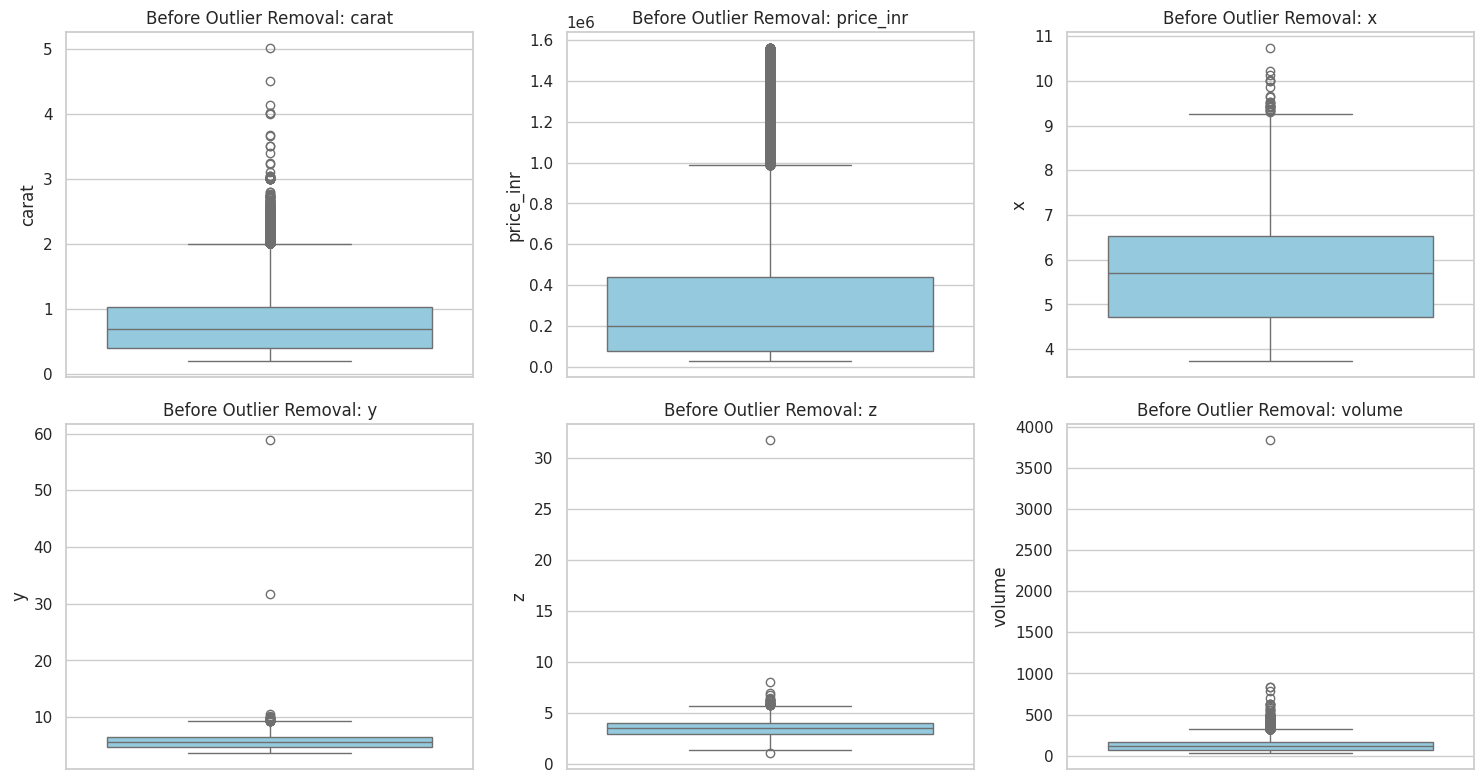

Removed 4452 rows containing outliers. New size: 49488


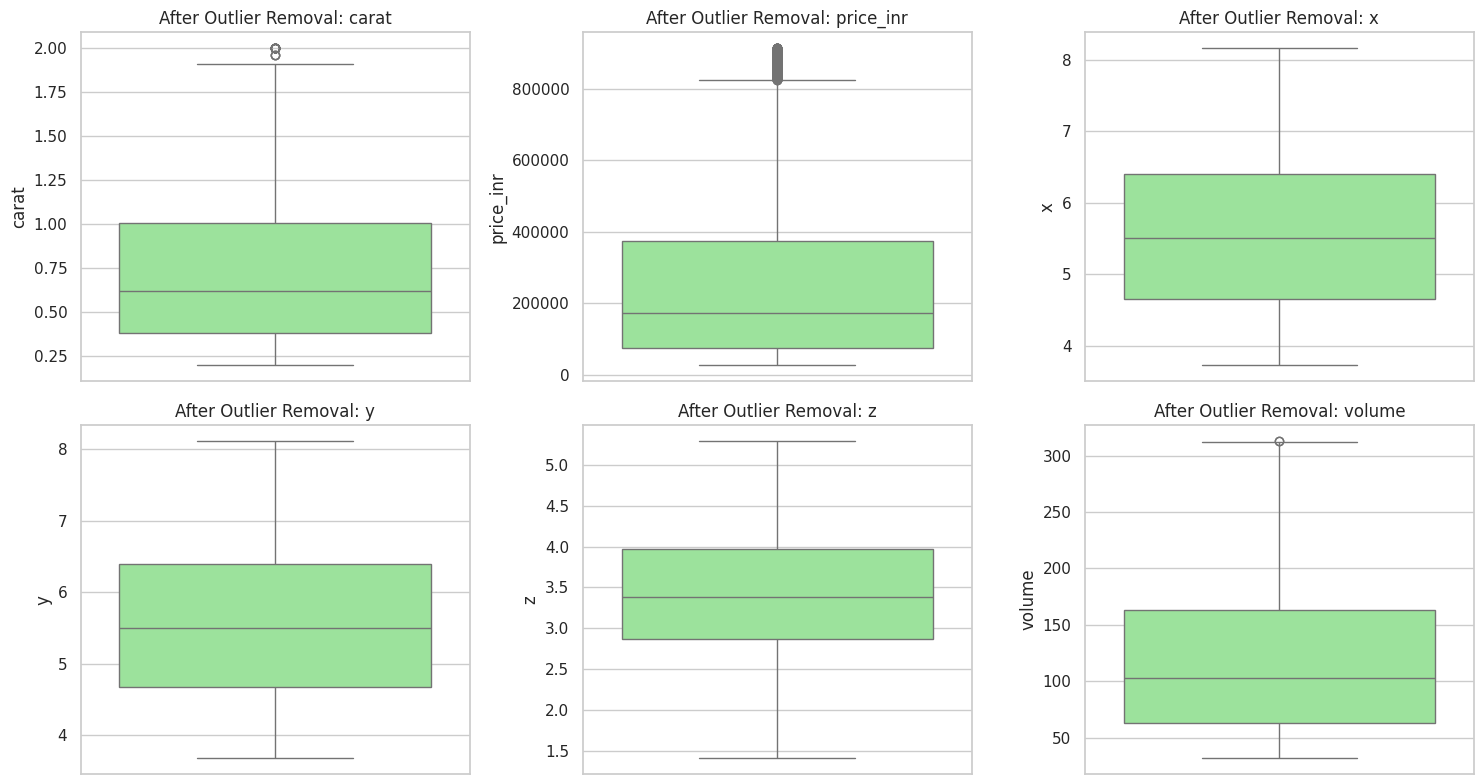

In [28]:
# Boxplots before outlier removal
plt.figure(figsize=(15, 8))
for i, col in enumerate(["carat", "price_inr", "x", "y", "z", "volume"]):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(f"Before Outlier Removal: {col}")
plt.tight_layout()
plt.show()


# Remove outliers
def remove_outliers_iqr(data, columns):
    df_clean = data.copy()
    initial_rows = len(df_clean)
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    print(
        f"Removed {initial_rows - len(df_clean)} rows containing outliers. New size: {len(df_clean)}"
    )
    return df_clean


numeric_cols = ["carat", "price_inr", "x", "y", "z", "volume"]
df_clean = remove_outliers_iqr(df, numeric_cols)

# Boxplots after outlier removal
plt.figure(figsize=(15, 8))
for i, col in enumerate(["carat", "price_inr", "x", "y", "z", "volume"]):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df_clean[col], color="lightgreen")
    plt.title(f"After Outlier Removal: {col}")
plt.tight_layout()
plt.show()

## Skewness Handling
Highly skewed features can negatively impact linear models and neural networks. We check the skewness using `.skew()` and apply `np.log1p` transformation to highly skewed features like `carat`, `price_inr`, and `volume`.

In [29]:
print("Skewness of features:")
print(df_clean[numeric_cols].skew())

# Apply log transforms
df_clean["carat_log"] = np.log1p(df_clean["carat"])
df_clean["price_inr_log"] = np.log1p(df_clean["price_inr"])
df_clean["volume_log"] = np.log1p(df_clean["volume"])

print("\nSkewness after log transforms:")
print(f"carat_log: {df_clean['carat_log'].skew():.4f}")
print(f"price_inr_log: {df_clean['price_inr_log'].skew():.4f}")
print(f"volume_log: {df_clean['volume_log'].skew():.4f}")

Skewness of features:
carat        0.647718
price_inr    1.126360
x            0.215162
y            0.210049
z            0.214749
volume       0.647448
dtype: float64

Skewness after log transforms:
carat_log: 0.3615
price_inr_log: 0.0300
volume_log: 0.0137


## Exploratory Data Analysis & Visualizations
We conduct Exploratory Data Analysis to identify correlations and visual trends.

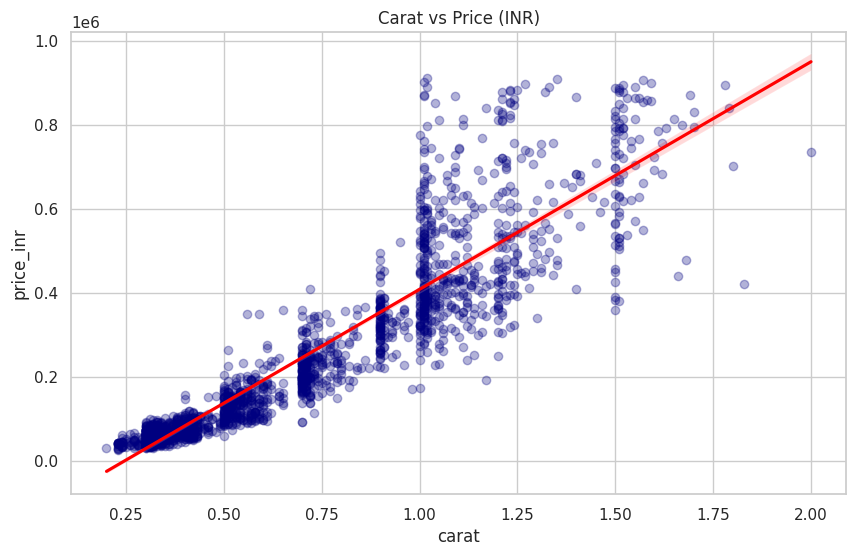

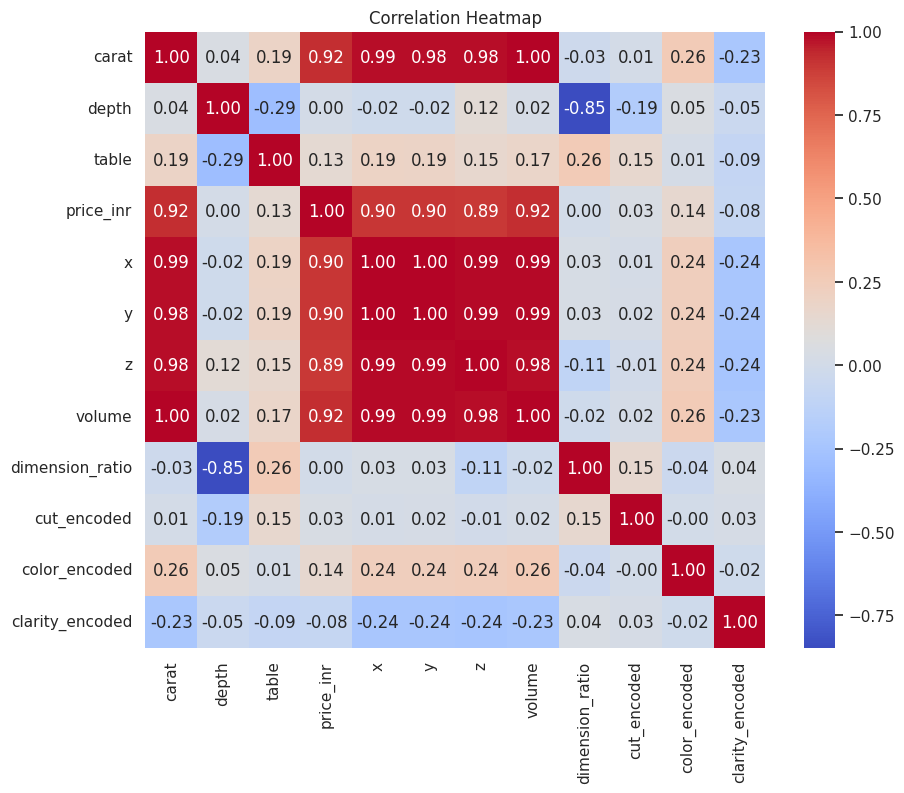

In [30]:
# 1. Carat vs Price Scatter with regression line
sns.regplot(
    data=df_clean.sample(2000),
    x="carat",
    y="price_inr",
    scatter_kws={"alpha": 0.3, "color": "navy"},
    line_kws={"color": "red"},
)
plt.title("Carat vs Price (INR)")
plt.show()

# 2. Heatmap
plt.figure(figsize=(10, 8))
corr_cols = [
    "carat",
    "depth",
    "table",
    "price_inr",
    "x",
    "y",
    "z",
    "volume",
    "dimension_ratio",
    "cut_encoded",
    "color_encoded",
    "clarity_encoded",
]
sns.heatmap(df_clean[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Feature Selection & Multicollinearity
We calculate the Variance Inflation Factor (VIF) to detect multicollinearity among the features.

In [31]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from statsmodels.tools.tools import add_constant

vif_features = [
    "carat",
    "depth",
    "table",
    "x",
    "y",
    "z",
    "volume",
    "dimension_ratio",
    "cut_encoded",
    "color_encoded",
    "clarity_encoded",
]

scaler_temp = StandardScaler()
X_temp = scaler_temp.fit_transform(df_clean[vif_features])

# 1. Scale the features
scaler_temp = StandardScaler()
X_temp = scaler_temp.fit_transform(df_clean[vif_features])

# 2. Add an intercept constant column (Adds a column of 1s at index 0)
X_with_const = add_constant(X_temp)

vif_data = pd.DataFrame()
vif_data["feature"] = vif_features

# 3. Loop starts at index 1 to skip evaluating the constant column itself
vif_data["VIF"] = [
    variance_inflation_factor(X_with_const, i) for i in range(1, X_with_const.shape[1])
]

print("Variance Inflation Factor (Corrected):")
print(vif_data.sort_values(by="VIF", ascending=False).round(2))

Variance Inflation Factor (Corrected):
            feature      VIF
5                 z  1336.60
6            volume   686.86
4                 y   667.08
0             carat   648.12
3                 x   613.62
7   dimension_ratio    13.19
1             depth    10.72
2             table     1.40
9     color_encoded     1.09
10  clarity_encoded     1.07
8       cut_encoded     1.07


## Regression Model Building (Price Prediction)
We split the data into an 80-20 train-test set, scale the features, and build five different ML regressors as well as an Artificial Neural Network (ANN) regressor. We evaluate them on the original price scale (reverting log transform via `np.expm1`).

## What is a Hyperparameter Search Space?
A hyperparameter search space is a defined set of values and ranges assigned to a model's hyperparameters for evaluation during tuning. [1, 2, 3]

* Hyperparameters are configurations set by the practitioner before training (like tree depth or learning rate). They cannot be learned directly from data. [4, 5, 6, 7, 8]
* The "Space" represents all possible combinations of these values. For example, if you test 3 values for max_depth and 3 values for n_estimators, your search space contains exactly $3 \times 3 = 9$ unique model combinations. [9, 10, 11]

## Why Loop Through Models and Execute GridSearchCV?
Looping through models and applying GridSearchCV automates the process of finding the absolute best model configuration for your specific dataset. [12, 13]
## 1. Why use a loop?

* Efficiency: It tests multiple distinct algorithms (e.g., Linear Regression vs. XGBoost) in a single run.
* No Manual Swapping: You avoid copying, pasting, and running separate code blocks for every different model type.
* Standardised Evaluation: It ensures every single model is evaluated using the exact same data splits and performance metrics, creating a fair competition.

## 2. Why use GridSearchCV?

* Exhaustive Evaluation: It systematically builds and evaluates a model for every single combination of parameters in your search space. [14, 15]
* Cross-Validation (cv=5): It splits your training data into 5 parts. It trains on 4 parts and tests on 1, rotating this process 5 times. This ensures your parameter selections are robust and not just lucky guesses on a single validation set. [16, 17, 18, 19, 20]
* Automation: It tracks performance automatically and isolates the single best-performing parameter combination (best_params_) without human intervention. [21, 22, 23]

In [37]:
import numpy as np
import pandas as pd
import xgboost as xgb

# === RAPIDS GPU IMPORTS ===
from cuml.model_selection import train_test_split, GridSearchCV
from cuml.preprocessing import StandardScaler
from cuml.metrics import mean_absolute_error, mean_squared_error, r2_score
from cuml.linear_model import Ridge
from cuml.ensemble import RandomForestRegressor
from cuml.neighbors import KNeighborsRegressor

# Note: DecisionTreeRegressor is not currently exposed directly in cuml.ensemble.
# We import it from cuml.tree instead.
from sklearn.tree import DecisionTreeRegressor

# 1. Define features and target
feature_cols = [
    "carat_log",
    "cut_encoded",
    "color_encoded",
    "clarity_encoded",
    "depth",
    "table",
    "volume_log",
    "carat_category_encoded",
]
X = df_clean[feature_cols]
y = df_clean["price_inr_log"]

# 2. Split data (Now processed directly on GPU memory if data is a cuDF DataFrame, or converted automatically)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale data (GPU Accelerated)
scaler_reg = StandardScaler()
X_train_scaled = scaler_reg.fit_transform(X_train)
X_test_scaled = scaler_reg.transform(X_test)

# 4. Initialize ML models (All set to run on GPU)
models = {
    "Linear Regression": Ridge(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        random_state=42
    ),  # n_jobs dropped; handles parallelization on GPU
    "XGBoost": xgb.XGBRegressor(random_state=42, device="cuda"),  # Native GPU parameter updated
    "KNN Regressor": KNeighborsRegressor(),  # n_jobs dropped
}

# 5. Define Hyperparameter Search Spaces
# Fixed: cuML Random Forest uses 'sqrt' and 'log2', but 'None' is handled by omitting or using standard parameters.
# cuML KNN only supports 'euclidean' natively for certain backends, so metric is simplified for maximum safety.
param_grids = {
    "Linear Regression": {"alpha": [0.1, 1.0, 10.0, 100.0], "fit_intercept": [True, False]},
    "Decision Tree": {
        "max_depth": [5, 10, 15, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
    },
    "Random Forest": {
        "n_estimators": [50, 100, 150],
        "max_depth": [10, 15, 20],
        "max_features": [
            0.3,
            0.5,
            1.0,
        ],  # cuML prefers float ratios instead of string names for max_features
    },
    "XGBoost": {
        "n_estimators": [100, 150, 200],
        "max_depth": [4, 6, 8],
        "learning_rate": [0.01, 0.1, 0.2],
        "subsample": [0.8, 1.0],
    },
    "KNN Regressor": {
        "n_neighbors": [3, 5, 7, 11],
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "manhattan"],
    },
}
# 6. Loop, execute GPU-accelerated GridSearchCV, and evaluate
results = {}

for name, model in models.items():
    print(f"Tuning and training {name} on GPU...")

    # Run Grid Search using cuML's GPU-native GridSearchCV
    # Note: n_jobs is removed here because the GPU handles cross-validation natively
    grid_search = GridSearchCV(
        estimator=model, param_grid=param_grids[name], cv=5, scoring="neg_mean_squared_error"
    )

    # Train using scaled data on the GPU
    grid_search.fit(X_train_scaled, y_train)
    best_model = grid_search.best_estimator_

    # Predict
    y_pred = best_model.predict(X_test_scaled)

    # Evaluate using cuML GPU metrics
    # cuML metrics sometimes return a CuPy array or GPU Series; .item() ensures standard Python types
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Store results
    results[name] = {
        "Best Params": grid_search.best_params_,
        "MAE": mae if isinstance(mae, float) else mae.item(),
        "RMSE": rmse if isinstance(rmse, float) else rmse.item(),
        "R2": r2 if isinstance(r2, float) else r2.item(),
    }

# 7. Display final performance comparison
df_results = pd.DataFrame(results).T
print("\n=== Model Performance Comparison ===")
print(df_results[["MAE", "RMSE", "R2"]])

Tuning and training Linear Regression on GPU...
Tuning and training Decision Tree on GPU...
Tuning and training Random Forest on GPU...
Tuning and training XGBoost on GPU...
Tuning and training KNN Regressor on GPU...

=== Model Performance Comparison ===
                        MAE      RMSE        R2
Linear Regression  0.150887  0.196953  0.952197
Decision Tree      0.085357  0.112631  0.984367
Random Forest      0.075354  0.099432  0.987816
XGBoost            0.071566  0.094517  0.988991
KNN Regressor      0.100977   0.13534  0.977427


In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

ann_model = Sequential(
    [
        Dense(128, activation="relu", input_shape=(len(feature_cols),)),
        Dropout(0.1),
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dense(1),
    ]
)
ann_model.compile(optimizer="adam", loss="mse")
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
ann_model.fit(
    X_train_scaled,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=0,
)


class ANNWrapper:
    def __init__(self, model):
        self.model = model

    def predict(self, X):
        return self.model.predict(X, verbose=0).flatten()


models["ANN Regressor"] = ANNWrapper(ann_model)
print("ANN Regressor successfully compiled and trained.")

# Evaluate
results = []
y_test_inr = np.expm1(y_test)

for name, model in models.items():
    # Only fit standard models; the ANN is already trained
    if name != "ANN Regressor":
        model.fit(X_train_scaled, y_train)

    # Generate predictions using the uniform .predict() structure
    y_pred_log = model.predict(X_test_scaled)
    y_pred_inr = np.expm1(y_pred_log)

    # Calculate performance metrics
    mae = mean_absolute_error(y_test_inr, y_pred_inr)
    mse = mean_squared_error(y_test_inr, y_pred_inr)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_inr, y_pred_inr)

    results.append({"Model": name, "MAE (INR)": mae, "RMSE (INR)": rmse, "R² Score": r2})

results_df = pd.DataFrame(results)
print(results_df.round(4))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


ANN Regressor successfully compiled and trained.
               Model   MAE (INR)  RMSE (INR)  R² Score
0  Linear Regression  37934.7937  65453.6921    0.9065
1      Decision Tree  22031.9280  38355.5417    0.9679
2      Random Forest  17109.4544  29009.6271    0.9816
3            XGBoost  16899.5234  28783.4594    0.9819
4      KNN Regressor  26110.5726  46407.1166    0.9530
5      ANN Regressor  24329.4024  41513.1184    0.9624


## Clustering Model Building (Market Segmentation)
We drop all price columns and segment the remaining physical features using K-Means clustering. We use the Elbow method and Silhouette score to determine optimal K, then project features to 2 principal components using PCA for 2D visualization.

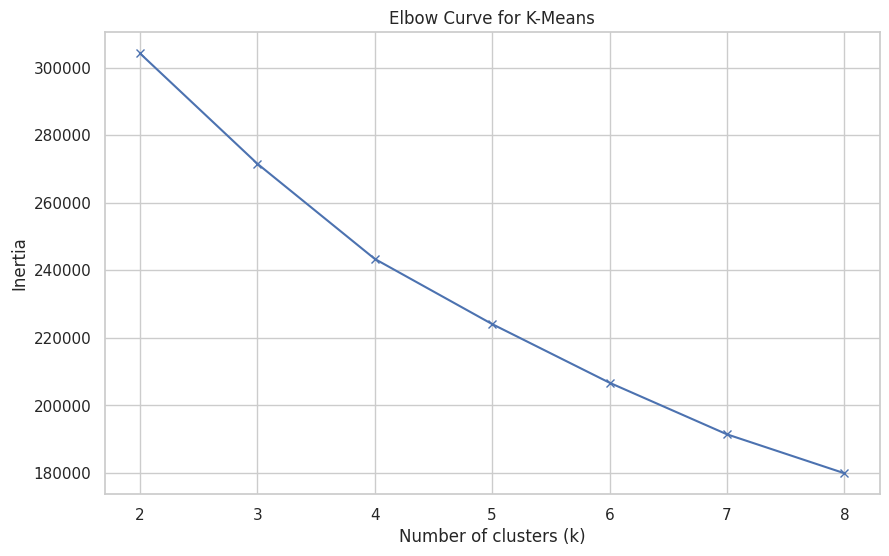

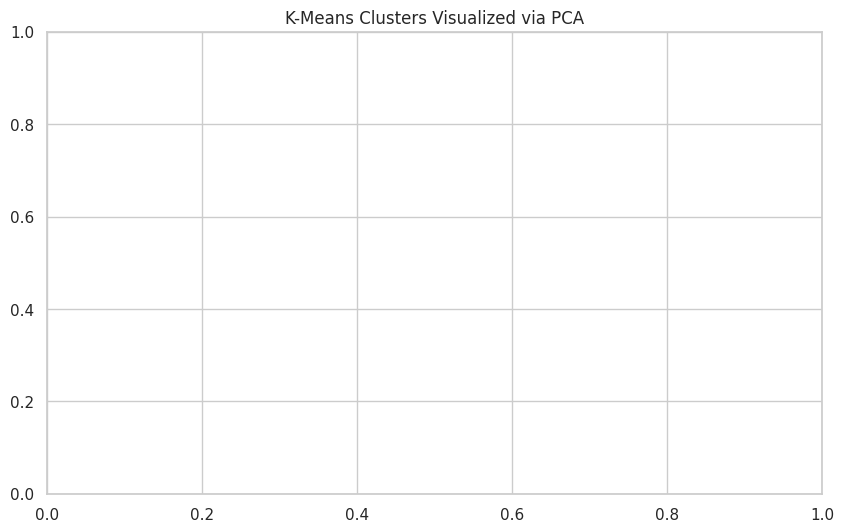

In [38]:
from cuml.cluster import KMeans
from cuml.decomposition import PCA

# Drop price-related features
cluster_feature_cols = [
    "carat",
    "cut_encoded",
    "color_encoded",
    "clarity_encoded",
    "depth",
    "table",
    "volume",
    "carat_category_encoded",
]
X_cluster = df_clean[cluster_feature_cols]

# Scale
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# Elbow Curve
inertia = []
K_range = range(2, 9)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, "bx-")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Curve for K-Means")
plt.show()

# Fit optimal K-Means (K=3)
best_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean["cluster"] = best_kmeans.fit_predict(X_cluster_scaled)

# Visualize with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)
df_pca = pd.DataFrame(X_pca, columns=["PCA1", "PCA2"])
df_pca["cluster"] = df_clean["cluster"].values

sns.scatterplot(data=df_pca, x="PCA1", y="PCA2", hue="cluster", palette="Set1", alpha=0.6)
plt.title("K-Means Clusters Visualized via PCA")
plt.show()

## Cluster Profiling & Commercial Naming
We profile each cluster by computing their mean properties. Based on physical weight (carat) and commercial pricing, we categorize and name them commercially.

In [39]:
cluster_profiles = (
    df_clean.groupby("cluster")
    .agg({"carat": "mean", "price_inr": "mean", "volume": "mean", "cut_encoded": "mean"})
    .reset_index()
)

print("Cluster Profiles:")
print(cluster_profiles)

# Map clusters
sorted_clusters = cluster_profiles.sort_values(by="carat").reset_index()
cluster_name_mapping = {}
cluster_name_mapping[sorted_clusters.iloc[0]["cluster"]] = "Affordable Small Diamonds"
cluster_name_mapping[sorted_clusters.iloc[1]["cluster"]] = "Mid-range Balanced Diamonds"
cluster_name_mapping[sorted_clusters.iloc[2]["cluster"]] = "Premium Heavy Diamonds"

print("\nMapped Names:")
for cid, name in cluster_name_mapping.items():
    print(f"Cluster {cid} -> {name}")

Cluster Profiles:
   cluster     carat      price_inr      volume  cut_encoded
0      0.0  0.416629  108865.347543   68.326331     2.550669
1      1.0  1.067564  452694.371589  173.302694     2.683462
2      2.0  0.675869  227721.111147  110.067680     2.450383

Mapped Names:
Cluster 0.0 -> Affordable Small Diamonds
Cluster 2.0 -> Mid-range Balanced Diamonds
Cluster 1.0 -> Premium Heavy Diamonds


In [40]:
import pandas as pd
import xgboost as xgb
from cuml.model_selection import GridSearchCV  # Ensure this is imported for GridSearchCV

# Define file paths
clustering_model_filename = "best_clustering_model.pkl"
regression_model_filename = "best_regression_model.pkl"
clustering_scaler_filename = "clustering_scaler.pkl"
regression_scaler_filename = "regression_scaler.pkl"
regression_results_filename = "regression_results.csv"
clustering_names_filename = "cluster_names.pkl"

# 1. Save best clustering model
with open(clustering_model_filename, "wb") as f:
    pickle.dump(best_kmeans, f)
print(f"Saved best clustering model to {clustering_model_filename}")

# 2. Save clustering scaler
with open(clustering_scaler_filename, "wb") as f:
    pickle.dump(scaler_cluster, f)
print(f"Saved clustering scaler to {clustering_scaler_filename}")

# 3. Save regression scaler
with open(regression_scaler_filename, "wb") as f:
    pickle.dump(scaler_reg, f)
print(f"Saved regression scaler to {regression_scaler_filename}")

# 4. Save best regression model (XGBoost)
# Re-run GridSearchCV specifically for XGBoost to retrieve the best estimator
# Make sure X_train_scaled and y_train are available in the kernel state
xgboost_model = xgb.XGBRegressor(random_state=42, device="cuda")
xgboost_param_grid = {
    "n_estimators": [100, 150, 200],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.8, 1.0],
}
grid_search_xgb = GridSearchCV(
    estimator=xgboost_model, param_grid=xgboost_param_grid, cv=5, scoring="neg_mean_squared_error"
)
grid_search_xgb.fit(X_train_scaled, y_train)
best_regression_model = grid_search_xgb.best_estimator_

with open(regression_model_filename, "wb") as f:
    pickle.dump(best_regression_model, f)
print(f"Saved best regression model to {regression_model_filename}")

# 5. Save regression results to CSV
results_df.to_csv(regression_results_filename, index=False)
print(f"Saved regression results to {regression_results_filename}")

# 6. Save cluster names
with open(clustering_names_filename, "wb") as f:
    pickle.dump(cluster_name_mapping, f)
print(f"Saved cluster names to {clustering_names_filename}")

print("\nAll requested files have been saved. You can download them from the Colab file browser.")

Saved best clustering model to best_clustering_model.pkl
Saved clustering scaler to clustering_scaler.pkl
Saved regression scaler to regression_scaler.pkl
Saved best regression model to best_regression_model.pkl
Saved regression results to regression_results.csv

All requested files have been saved. You can download them from the Colab file browser.
